#1. Configuração do Ambiente e Base de Dados

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Configuração de estilo global do Seaborn
sns.set_theme(style="whitegrid", palette="muted")

# Geração de dados sintéticos
np.random.seed(101)
n = 300

In [ ]:
dados = {
    'idade': np.random.normal(35, 10, n).astype(int),
    'plano': np.random.choice(['Gratuito', 'Básico', 'Pro'], n, p=[0.5, 0.3, 0.2]),
    'tempo_uso_horas': np.random.uniform(1, 50, n),
    'bugs_reportados': np.random.poisson(2, n),
    'satisfacao': np.random.randint(1, 11, n)
}

df_sistema = pd.DataFrame(dados)

In [ ]:
# Ajustando regras de negócio sintéticas para gerar correlações visuais
df_sistema.loc[df_sistema['plano'] == 'Pro', 'tempo_uso_horas'] += 15
df_sistema.loc[df_sistema['plano'] == 'Pro', 'satisfacao'] += 2
df_sistema['satisfacao'] = df_sistema['satisfacao'] - (df_sistema['bugs_reportados'] * 0.5)
df_sistema['satisfacao'] = df_sistema['satisfacao'].clip(1, 10).astype(int)
df_sistema['idade'] = df_sistema['idade'].clip(18, 70)

#2. Roteiro de Tarefas

##Parte 1: Distribuições e Contagens (Básico)

Crie um gráfico de barras para exibir a contagem de usuários por tipo de plano. Utilize a função countplot e ordene as barras pela frequência.

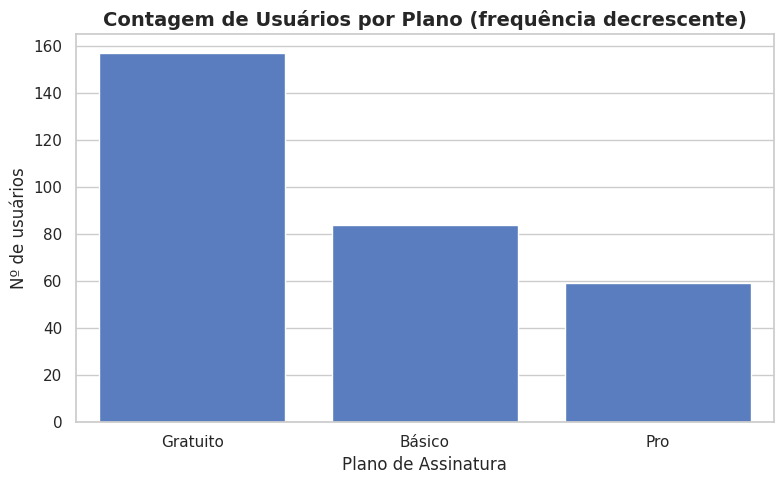

In [ ]:
ordem_planos = df_sistema['plano'].value_counts().index  # decrescente por frequência

plt.figure(figsize=(8, 5))
sns.countplot(data=df_sistema, x='plano', order=ordem_planos)

plt.title('Contagem de Usuários por Plano (frequência decrescente)', fontsize=14, fontweight='bold')
plt.xlabel('Plano de Assinatura')
plt.ylabel('Nº de usuários')

plt.tight_layout()
plt.show()

Analise a distribuição da variável idade utilizando um histplot. Adicione a curva de densidade (KDE) para suavizar a visualização.

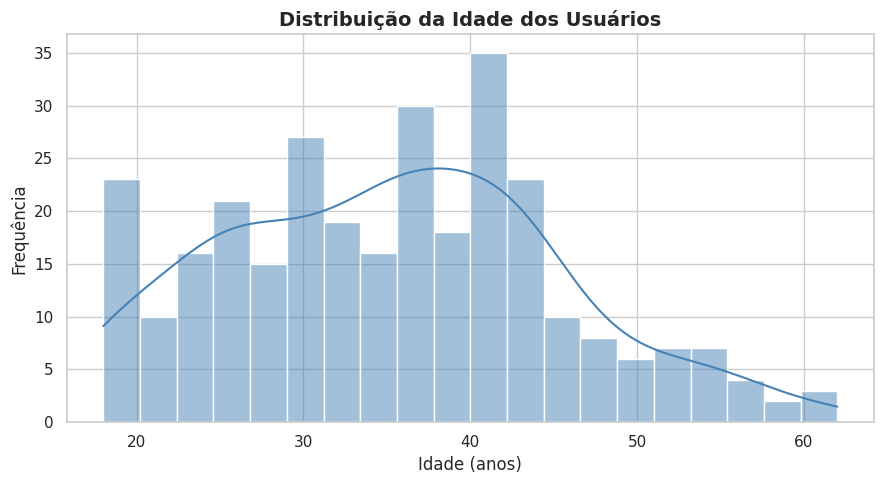

Idade média: 35.2 | mediana: 36


In [ ]:
plt.figure(figsize=(9, 5))
sns.histplot(data=df_sistema, x='idade', bins=20, kde=True, color='steelblue')

plt.title('Distribuição da Idade dos Usuários', fontsize=14, fontweight='bold')
plt.xlabel('Idade (anos)')
plt.ylabel('Frequência')

plt.tight_layout()
plt.show()
print(f"Idade média: {df_sistema['idade'].mean():.1f} | mediana: {df_sistema['idade'].median():.0f}")

##Parte 2: Relações Categóricas e Numéricas (Intermediário)

Construa um boxplot para comparar a distribuição do tempo_uso_horas entre os diferentes tipos de plano.

          count  mean   std   min   25%   50%   75%   max
plano                                                    
Básico     84.0  22.0  13.0   1.0  11.1  21.9  31.1  48.6
Gratuito  157.0  25.2  14.0   1.9  13.5  25.8  37.5  50.0
Pro        59.0  40.1  15.1  16.3  26.0  37.6  55.5  63.1


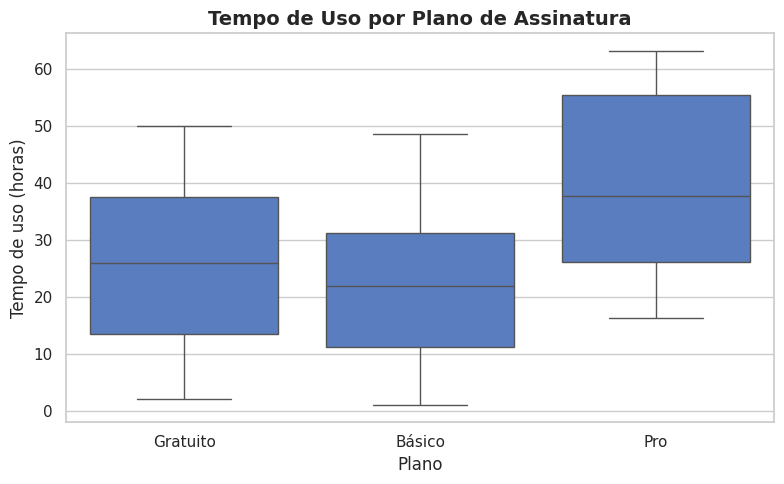

In [ ]:
print(df_sistema.groupby('plano')['tempo_uso_horas'].describe().round(1))

plt.figure(figsize=(8, 5))
sns.boxplot(data=df_sistema, x='plano', y='tempo_uso_horas', order=ordem_planos)

plt.title('Tempo de Uso por Plano de Assinatura', fontsize=14, fontweight='bold')
plt.xlabel('Plano')
plt.ylabel('Tempo de uso (horas)')

plt.tight_layout()
plt.show()

Crie um violinplot cruzando o plano com a satisfacao. Esse gráfico ajudará a entender não apenas a mediana, mas a densidade das notas dadas pelos clientes de cada plano.

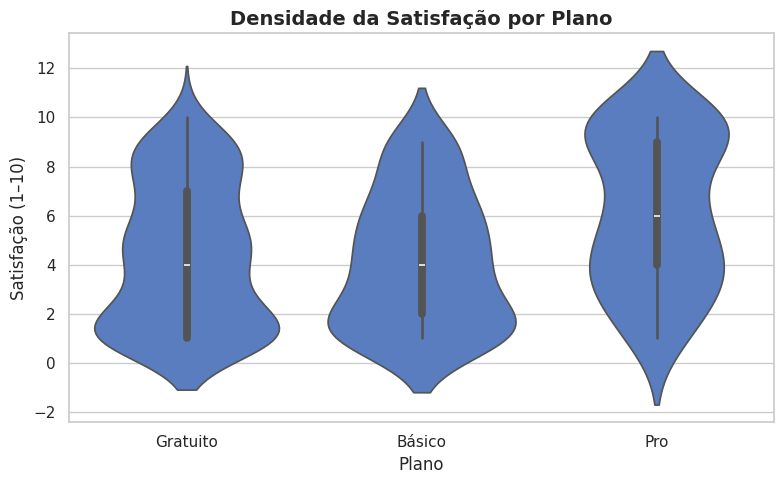

In [ ]:
plt.figure(figsize=(8, 5))
sns.violinplot(data=df_sistema, x='plano', y='satisfacao', order=ordem_planos)

plt.title('Densidade da Satisfação por Plano', fontsize=14, fontweight='bold')
plt.xlabel('Plano')
plt.ylabel('Satisfação (1–10)')

plt.tight_layout()
plt.show()

##Parte 3: Correlações e Análise Multivariada (Avançado)

Utilize um scatterplot para investigar a relação entre tempo_uso_horas (eixo X) e satisfacao (eixo Y). Utilize o parâmetro hue para colorir os pontos de acordo com o plano e size para variar o tamanho dos pontos com base nos bugs_reportados.

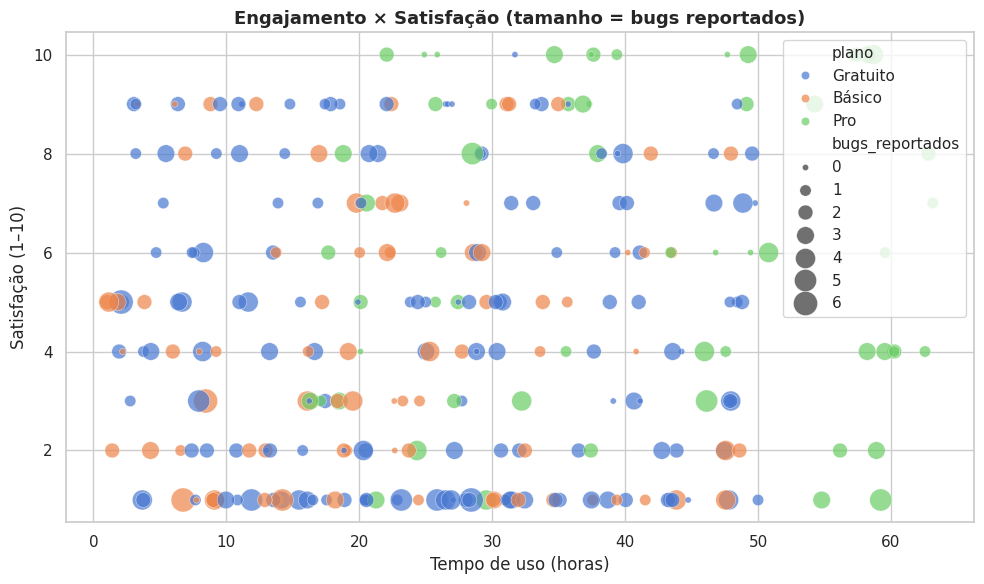

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_sistema,
                x='tempo_uso_horas', y='satisfacao',
                hue='plano', size='bugs_reportados',
                sizes=(20, 300), alpha=0.7)

plt.title('Engajamento × Satisfação (tamanho = bugs reportados)', fontsize=13, fontweight='bold')
plt.xlabel('Tempo de uso (horas)')
plt.ylabel('Satisfação (1–10)')

plt.tight_layout()
plt.show()

Calcule a matriz de correlação de Pearson apenas para as variáveis numéricas do DataFrame e visualize-a utilizando um heatmap. Configure a paleta de cores para divergir do centro (ex: 'coolwarm' ou 'vlag') e ative as anotações numéricas (annot=True).

                 idade  tempo_uso_horas  bugs_reportados  satisfacao
idade            1.000           -0.042            0.059      -0.046
tempo_uso_horas -0.042            1.000           -0.035       0.082
bugs_reportados  0.059           -0.035            1.000      -0.219
satisfacao      -0.046            0.082           -0.219       1.000


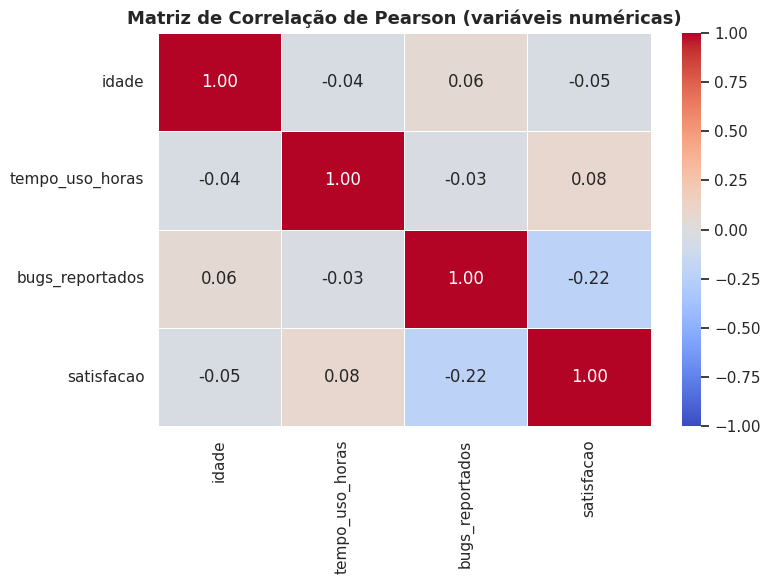

In [ ]:
corr = df_sistema.select_dtypes(include=[np.number]).corr(method='pearson')
print(corr.round(3))

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f',
            linewidths=0.5, vmin=-1, vmax=1)
plt.title('Matriz de Correlação de Pearson (variáveis numéricas)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

(Bônus) Gere um pairplot englobando as variáveis tempo_uso_horas, bugs_reportados e satisfacao, utilizando o plano como hue.

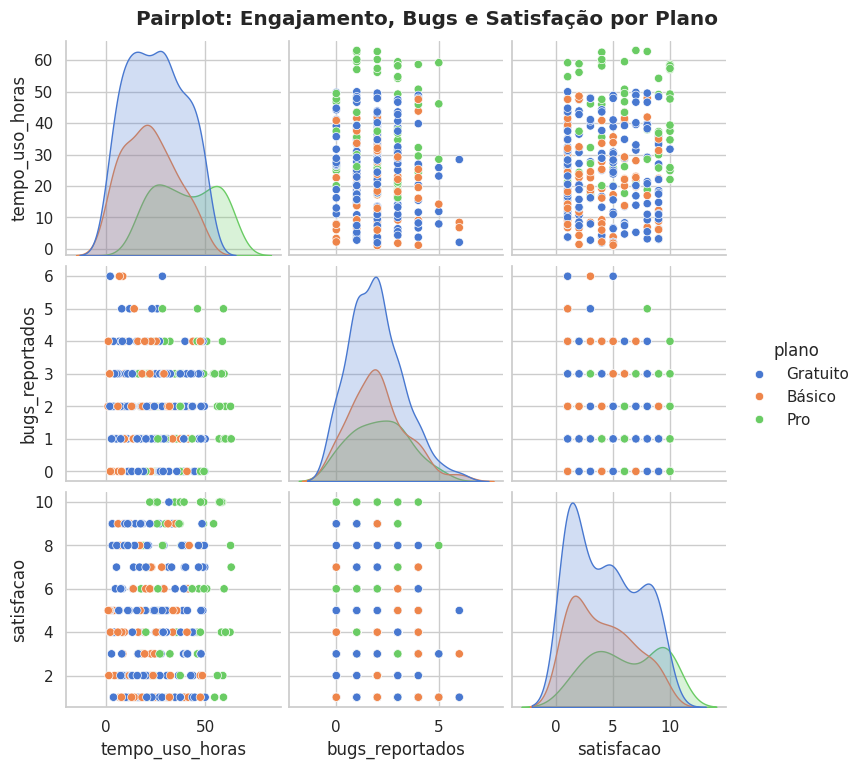

In [ ]:
g = sns.pairplot(data=df_sistema[['tempo_uso_horas', 'bugs_reportados', 'satisfacao', 'plano']],
                 hue='plano', kind='scatter', diag_kind='kde', palette='muted')
g.fig.suptitle('Pairplot: Engajamento, Bugs e Satisfação por Plano', y=1.02, fontweight='bold')
plt.show()